# Notebook 2 — Clustering y Análisis de Fenotipos
## Identificación de Fenotipos de Pacientes con Insuficiencia Cardíaca
**Proyecto Curso I — Especialización Machine Learning Engineering**  
Ramos Miranda, Jaime

---
Este notebook cubre la determinación del número óptimo de clusters, el modelo K-Means,
la caracterización de fenotipos y la validación clínica externa.  
**Requiere haber ejecutado primero `01_preprocesamiento.ipynb`.**

## 1. Librerías

In [1]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

import warnings
warnings.filterwarnings("ignore")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga de datos preprocesados

In [3]:
# Cargar datos estandarizados
X = pd.read_csv('../data/datos_estandarizados.csv')
target = pd.read_csv('../data/target.csv')
df_original = pd.read_csv('../data/datos_originales_limpios.csv')

print(f"Datos para clustering: {X.shape}")
X.head()

Datos para clustering: (283, 12)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,1.192945,-0.871105,0.000166,-0.847579,-1.530560,1.359272,0.016816,0.490057,-1.504036,0.735688,-0.687682,-1.629502
1,0.350833,-0.871105,-0.449939,-0.847579,-1.530560,-0.735688,-1.038073,-0.090900,-1.731046,0.735688,1.454161,-1.590785
2,-0.912335,1.147968,-0.486071,-0.847579,-1.530560,-0.735688,-0.546474,0.490057,0.085034,0.735688,-0.687682,-1.590785
3,2.456114,1.147968,-0.552141,-0.847579,0.162199,1.359272,-0.607924,0.683709,-1.050016,0.735688,1.454161,-1.577879
4,1.192945,1.147968,-0.346704,-0.847579,-1.953749,-0.735688,-1.396531,-0.187726,0.085034,0.735688,-0.687682,-1.552067


## 3. Determinación del número óptimo de clusters (k)

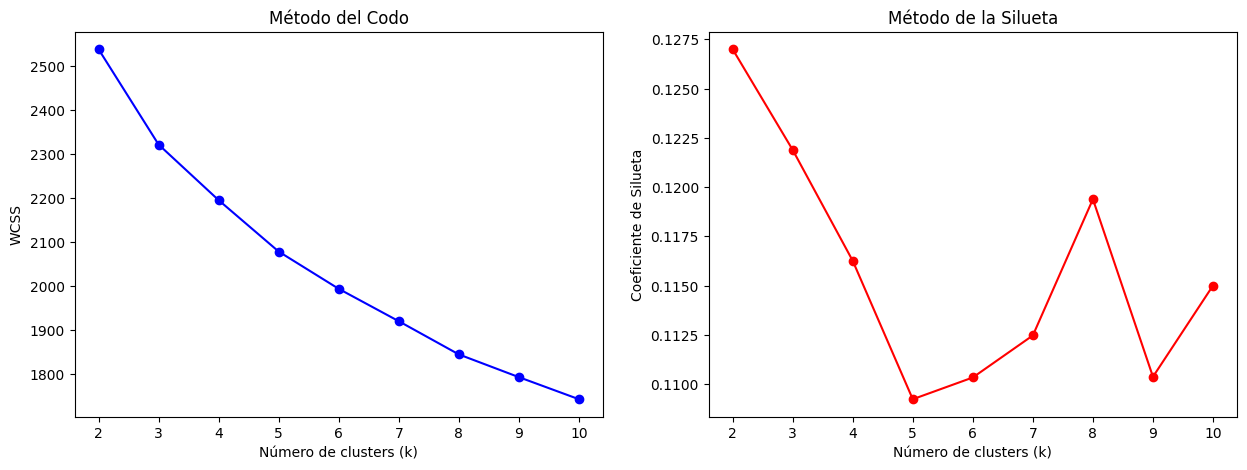

In [4]:
# Método del Codo e Índice de Silueta
wcss = []
sil = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=2020)
    labels = kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)
    sil.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(k_range, wcss, 'bo-')
ax1.set_title('Método del Codo')
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('WCSS')

ax2.plot(k_range, sil, 'ro-')
ax2.set_title('Método de la Silueta')
ax2.set_xlabel('Número de clusters (k)')
ax2.set_ylabel('Coeficiente de Silueta')

plt.show()

## 4. Entrenamiento del modelo K-Means (k=4)

In [5]:
k_optimo = 4
kmeans_final = KMeans(n_clusters=k_optimo, n_init=20, random_state=2020)
clusters = kmeans_final.fit_predict(X)

# Añadir etiquetas al dataframe original
df_final = df_original.copy()
df_final['fenotipo'] = clusters + 1
df_final['DEATH_EVENT'] = target['DEATH_EVENT']

print("Distribución de pacientes por fenotipo:")
print(df_final['fenotipo'].value_counts().sort_index())

Distribución de pacientes por fenotipo:
fenotipo
1    69
2    79
3    90
4    45
Name: count, dtype: int64


## 5. Visualización con PCA

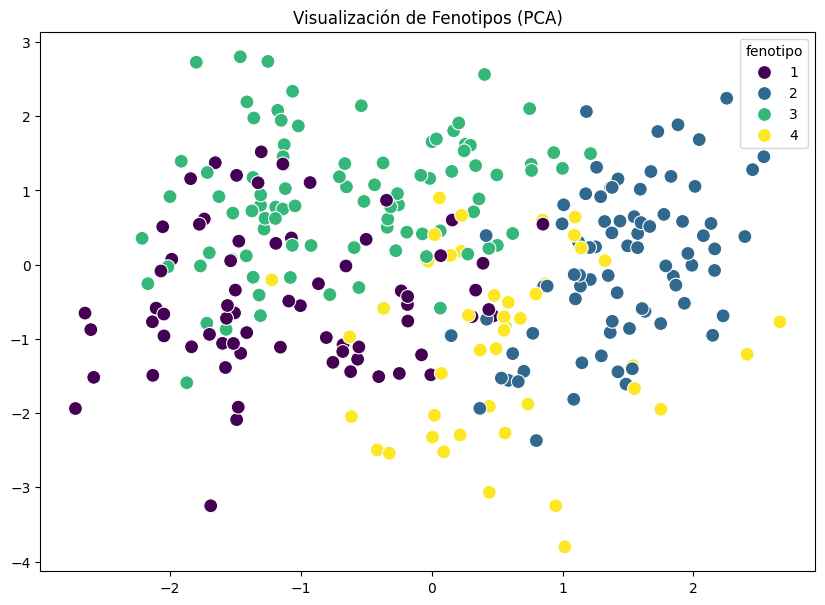

In [6]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=df_final['fenotipo'], palette='viridis', s=100)
plt.title('Visualización de Fenotipos (PCA)')
plt.show()

## 6. Caracterización y Exportación

In [7]:
# Resumen de promedios
perfil_cont = df_final.groupby('fenotipo').mean()
print(perfil_cont)

# Exportar resultados
df_final.to_csv('../artifacts/heart_failure_con_fenotipos.csv', index=False)

with pd.ExcelWriter("../artifacts/cuadros_fenotipos.xlsx", engine="openpyxl") as writer:
    perfil_cont.to_excel(writer, sheet_name="Resumen Fenotipos")

print("Archivos exportados en artifacts/.")

                age   anaemia  creatinine_phosphokinase  diabetes  \
fenotipo                                                            
1         60.458942  0.463768                438.913043  0.449275   
2         59.670886  0.354430                469.037975  0.316456   
3         56.918522  0.455556                528.855556  0.555556   
4         71.688889  0.466667                390.022222  0.244444   

          ejection_fraction  high_blood_pressure      platelets  \
fenotipo                                                          
1                 39.173913             1.000000  268881.016667   
2                 37.708861             0.291139  260512.736835   
3                 40.655556             0.000000  265005.912444   
4                 31.066667             0.200000  229136.626222   

          serum_creatinine  serum_sodium       sex   smoking        time  \
fenotipo                                                                   
1                 1.106812    

---
## ✅ Resumen de resultados

| Métrica | Valor |
|---|---|
| Algoritmo | K-Means (k=4) |
| Silueta | 0.1163 |
| Davies-Bouldin | 2.3085 |
| Calinski-Harabasz | 29.79 |
| Inercia (WSS) | 2194.36 |

| Fenotipo | N | Mortalidad | Perfil clave |
|---|---|---|---|
| F1 | 69 | 27.5% | 100% hipertensión, mayoría mujeres |
| F2 | 79 | 24.1% | 100% masculino, 100% fumador |
| F3 | 90 | 16.7% | Más jóvenes, mejor función cardíaca |
| F4 | 45 | **73.3%** | Mayor edad, creatinina alta, sodio bajo ⚠️ |